# Random Forest Classifier — S&P 500 Direction Prediction

---

## Overview

This notebook develops a **Random Forest classifier** to predict the daily directional movement
(Up vs. Down) of the S&P 500 index. The feature set combines **NLP-derived signals** from
Wall Street Journal headlines with traditional market indicators.

| Component | Detail |
|-----------|--------|
| **Target** | `direction` → binary `target` (1 = Up, 0 = Down) |
| **Features** | 12 signal-map keyword counts + 2 BERT sentiment scores + `oil_close` + `vix_close` |
| **Pipeline** | `SimpleImputer` → `MaxAbsScaler` → `RandomForestClassifier` |
| **Tuning** | `GridSearchCV` with G-Mean scoring |
| **Hold-out** | 80/20 stratified train/test split |
| **Validation** | 5-fold Stratified CV on training set only (all preprocessing inside pipeline) |

### Data Leakage Prevention Protocol

A common pitfall in machine learning is **data leakage** — allowing information from the
evaluation set to influence model building. This notebook enforces strict separation:

1. **The dataset is split 80/20 upfront** using `train_test_split` with stratification.
2. **All model selection** (GridSearchCV, cross-validation) uses **only the training set**.
3. **The test set is touched exactly once** — after the best model is fully selected — for
   final unbiased evaluation.
4. **Permutation importance** is computed on the **test set** using the trained best model,
   ensuring feature importance reflects true generalization, not memorized training patterns.
5. **All preprocessing** (imputation, scaling) is encapsulated inside the `Pipeline`, so it
   is fitted only on training folds and applied to validation/test folds without leakage.

### Why G-Mean Instead of Accuracy?

In financial prediction the class distribution is often skewed. **Accuracy** can be misleading
because a naïve model that always predicts the majority class achieves deceptively high accuracy.
The **Geometric Mean (G-Mean)** penalizes models that sacrifice one class for the other:

$$\text{G-Mean} = \sqrt{\text{Sensitivity} \times \text{Specificity}} = \sqrt{\text{Recall}_{\text{Up}} \times \text{Recall}_{\text{Down}}}$$


---
## Imports & Configuration

All libraries are imported here in a single cell for clarity and reproducibility.
Key choices:

- **`RandomForestClassifier`** — Ensemble of bagged decision trees; handles mixed feature
  types, robust to outliers, provides built-in feature importance.
- **`MaxAbsScaler`** — Chosen over `StandardScaler` because our keyword-count features are
  highly sparse (many zeros). `MaxAbsScaler` preserves the zero structure.
- **`train_test_split`** — Creates the 80/20 stratified hold-out split.
- **`SEED = 42`** — Fixed random state for full reproducibility.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Standard Libraries
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════
# Scikit-Learn
# ══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, make_scorer, recall_score
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# ══════════════════════════════════════════════════════════════
# Explainability & Complexity
# ══════════════════════════════════════════════════════════════
import shap
import problexity as px

# ══════════════════════════════════════════════════════════════
# Global Settings
# ══════════════════════════════════════════════════════════════
matplotlib.rcParams['figure.dpi'] = 130
SEED = 42
np.random.seed(SEED)

print('All imports OK')

All imports OK


---
## Data Loading & Feature Definition

The dataset `wsj_market_features.csv` contains daily observations indexed by date.
Each row represents one trading day and includes:

- **12 keyword-count features** derived from a signal-map applied to WSJ headlines.
  These capture thematic categories such as trade-war rhetoric (`TRADE_WAR`), Federal Reserve
  policy language (`FED_POLICY`), and market sentiment extremes (`FEAR_CRISIS`, `EUPHORIA_MOMENTUM`).
  These features are inherently **sparse** — on most days, many categories have zero mentions.

- **2 BERT-based sentiment scores** (`bert_sentiment`, `finbert_sentiment`) — continuous values
  from pre-trained transformer models applied to the same headlines.

- **2 market control variables** (`oil_close`, `vix_close`) — closing prices of crude oil and the
  VIX volatility index, included as exogenous market context.

- **Target** (`target`) — binary label where 1 = market moved Up, 0 = market moved Down.

In [2]:
df = pd.read_csv('wsj_market_features.csv', parse_dates=['date'], index_col='date')

feature_cols = [
    # 12 signal-map keyword counts (many zeros — sparse)
    'TRADE_WAR', 'FED_POLICY', 'FEAR_CRISIS', 'EARNINGS',
    'EUPHORIA_MOMENTUM', 'GEOPOLITICAL', 'SECTOR_TRIGGER',
    'ENERGY_COMMODITY', 'LABOR_CONSUMER', 'TRUMP_POLICY',
    'CRYPTO_FINTECH', 'AMPLIFIER_MOD',
    # 2 BERT sentiment scores
    'bert_sentiment', 'finbert_sentiment',
    # 2 market controls
    'oil_close', 'vix_close',
]

X = df[feature_cols].copy()
y = df['target'].copy()

print(f'Full dataset shape : {X.shape}')
print(f'Date range         : {X.index.min().date()} → {X.index.max().date()}')
print(f'Number of features : {len(feature_cols)}')
print(f'Number of samples  : {len(y):,}')

Full dataset shape : (2059, 16)
Date range         : 2018-01-03 → 2026-03-11
Number of features : 16
Number of samples  : 2,059


---
## Stratified Train/Test Split (80/20)

**This is the most critical cell in the entire notebook.** Before any modeling, exploration
of feature importance, or hyperparameter tuning, we partition the data into:

- **Training set (80%)** — Used for all model selection: cross-validation, grid search,
  and fitting the final model.
- **Test set (20%)** — Held out and **never touched** until Section 10. This provides an
  unbiased estimate of generalization performance.

We use `stratify=y` to ensure both sets preserve the original class distribution. Without
stratification, the minority class could be underrepresented in one split, biasing results.

**After this cell, the test set (`X_test`, `y_test`) must not be used for any purpose**
**other than final evaluation and test-set-based diagnostics (permutation importance, SHAP).**

In [ ]:
random.seed(time.time())
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print(f'Training set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X):.0%})')
print(f'Test set     : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X):.0%})')
print()
print('Class distribution verification:')
print(f'  Full data  — Up: {y.mean():.3f}  Down: {1-y.mean():.3f}')
print(f'  Train set  — Up: {y_train.mean():.3f}  Down: {1-y_train.mean():.3f}')
print(f'  Test set   — Up: {y_test.mean():.3f}  Down: {1-y_test.mean():.3f}')
print()
print('→ Stratification preserved. Class ratios are consistent across splits.')

Training set : 1,647 samples (80%)
Test set     : 412 samples (20%)

Class distribution verification:
  Full data  — Up: 0.546  Down: 0.454
  Train set  — Up: 0.546  Down: 0.454
  Test set   — Up: 0.546  Down: 0.454

→ Stratification preserved. Class ratios are consistent across splits.


---
## Dataset Complexity Analysis

Before building a model, it is instructive to quantify the **intrinsic difficulty** of the
classification task. The `problexity` library computes a suite of data complexity measures
that characterize class overlap, feature discriminability, and neighborhood separability.

We compute complexity on the **training set only** to avoid any information from the test set
influencing our understanding of the problem.

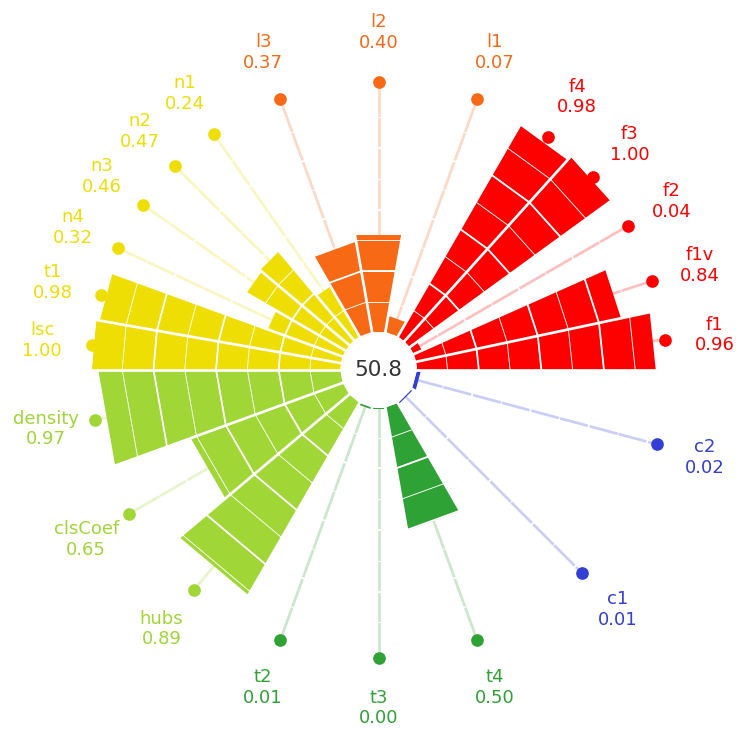

In [ ]:
random.seed(time.time())
# Impute missing values for complexity analysis (training set only)
imputer_temp = SimpleImputer(strategy='mean')
X_train_imputed = imputer_temp.fit_transform(X_train)

cc = px.ComplexityCalculator()
cc.fit(X_train_imputed, y_train)

fig = plt.figure(figsize=(7, 7))
cc.plot(fig, (1, 1, 1))
fig.savefig('dataset_complexity_plot.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Data Quality Audit (Training Set)

We perform three essential checks on the **training set**:

**Missing Values** — Are there NaNs that the imputer will need to handle?

**Zero Density** — What fraction of each feature is exactly zero? This justifies
choosing `MaxAbsScaler` over `StandardScaler`. When features are dominated by zeros
(as keyword counts typically are), `StandardScaler` shifts the zero-peak away from
the origin, destroying the natural sparsity. `MaxAbsScaler` divides by the max absolute
value, so zeros remain zeros.

**Class Balance** — How skewed is the target? Even moderate imbalance (e.g., 55/45)
motivates `class_weight='balanced'` and G-Mean as the evaluation metric.

In [ ]:
# Missing values (training set) ────────────────────────
nulls = X_train.isnull().sum()
print('MISSING VALUES (Training Set):')
if nulls.sum() == 0:
    print('  None found (imputer will still guard against future nulls)\n')
else:
    print(nulls[nulls > 0])
    print()

# Zero density per feature (training set) ──────────────
print('ZERO DENSITY (% of training rows that are exactly 0):')
zero_pct = (X_train == 0).mean().sort_values(ascending=False) * 100
for feat, pct in zero_pct.items():
    bar = '█' * int(pct / 2)
    print(f'  {feat:25s}  {pct:5.1f}%  {bar}')
print(f'\n→ High zero-density confirms MaxAbsScaler is the right choice.\n')

# Target distribution (training set) ──────────────────
up   = int(y_train.sum())
down = int(len(y_train) - up)
print(f'TARGET DISTRIBUTION (Training Set):')
print(f'  Up   (1): {up:,}  ({y_train.mean():.1%})')
print(f'  Down (0): {down:,}  ({1 - y_train.mean():.1%})')
print(f'  Imbalance ratio: {max(up, down) / min(up, down):.2f}:1')

MISSING VALUES (Training Set):
vix_close    1
dtype: int64

ZERO DENSITY (% of training rows that are exactly 0):
  CRYPTO_FINTECH              33.8%  ████████████████
  TRADE_WAR                   29.9%  ██████████████
  FEAR_CRISIS                 19.3%  █████████
  EARNINGS                    16.6%  ████████
  FED_POLICY                  10.6%  █████
  ENERGY_COMMODITY             9.7%  ████
  LABOR_CONSUMER               8.1%  ████
  AMPLIFIER_MOD                3.6%  █
  SECTOR_TRIGGER               2.8%  █
  TRUMP_POLICY                 2.2%  █
  EUPHORIA_MOMENTUM            0.7%  
  GEOPOLITICAL                 0.5%  
  bert_sentiment               0.0%  
  finbert_sentiment            0.0%  
  oil_close                    0.0%  
  vix_close                    0.0%  

→ High zero-density confirms MaxAbsScaler is the right choice.

TARGET DISTRIBUTION (Training Set):
  Up   (1): 900  (54.6%)
  Down (0): 747  (45.4%)
  Imbalance ratio: 1.20:1


---
## Define the G-Mean Scorer

In [6]:
def geometric_mean_score(y_true, y_pred):
    """G-Mean = sqrt(Recall_positive * Recall_negative)."""
    sensitivity = recall_score(y_true, y_pred, pos_label=1)   # TPR
    specificity = recall_score(y_true, y_pred, pos_label=0)   # TNR
    return np.sqrt(sensitivity * specificity)

gmean_scorer = make_scorer(geometric_mean_score, greater_is_better=True)

# Sanity check
assert abs(geometric_mean_score(
    np.array([1, 1, 0, 0]),
    np.array([1, 0, 0, 1])
) - 0.5) < 1e-6, 'G-Mean scorer failed sanity check'
print('G-Mean scorer OK  (√(0.5 × 0.5) = 0.5 ✓)')

G-Mean scorer OK  (√(0.5 × 0.5) = 0.5 ✓)


---
## Build Pipeline & Hyperparameter Grid

In [ ]:
random.seed(time.time())
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  MaxAbsScaler()),
    ('rf',      RandomForestClassifier(
                    class_weight='balanced',
                    random_state=SEED,
                    n_jobs=-1,
                )),
])

param_grid = {
    'rf__n_estimators':     [300, 500, 800],
    'rf__max_depth':        [5, 8, 12, None],
    'rf__min_samples_leaf': [10, 20, 40],
    'rf__max_features':     ['sqrt', 'log2'],
}

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)

print(f'Grid: {total_combos} combinations × 5 folds = {total_combos * 5} fits')
print(f'Pipeline: {" → ".join([name for name, _ in pipe.steps])}')

Grid: 72 combinations × 5 folds = 360 fits
Pipeline: imputer → scaler → rf


---
## GridSearchCV on Training Data Only

In [ ]:
random.seed(time.time())
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=gmean_scorer,
    cv=cv,
    refit=True,
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print('Running GridSearchCV on TRAINING DATA ONLY...\n')
grid_search.fit(X_train, y_train)    # ← ONLY training data

print(f'\n{"═" * 65}')
print(f'BEST CV G-MEAN (on training folds): {grid_search.best_score_:.4f}')
print(f'{"═" * 65}')
print('Best hyperparameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:30s} = {v}')

Running GridSearchCV on TRAINING DATA ONLY...

Fitting 5 folds for each of 72 candidates, totalling 360 fits

═════════════════════════════════════════════════════════════════
BEST CV G-MEAN (on training folds): 0.5922
═════════════════════════════════════════════════════════════════
Best hyperparameters:
  rf__max_depth                  = 5
  rf__max_features               = sqrt
  rf__min_samples_leaf           = 10
  rf__n_estimators               = 500


### Top 10 Grid Search Configurations

Inspecting the top configurations helps understand sensitivity to each hyperparameter
and detect overfitting (large train-test gap within CV).

In [9]:
cv_df = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')

top10 = cv_df[['params', 'mean_test_score', 'std_test_score',
               'mean_train_score']].head(10).reset_index(drop=True)
top10.columns = ['params', 'mean_gmean_cv', 'std_gmean_cv', 'mean_gmean_train']

print('Top 10 configurations by CV G-Mean:\n')
for i, row in top10.iterrows():
    gap = row['mean_gmean_train'] - row['mean_gmean_cv']
    print(f'  #{i+1:2d}  cv={row["mean_gmean_cv"]:.4f}±{row["std_gmean_cv"]:.4f}  '
          f'train={row["mean_gmean_train"]:.4f}  gap={gap:+.4f}')
    p = row['params']
    print(f'       trees={p["rf__n_estimators"]} depth={p["rf__max_depth"]} '
          f'leaf={p["rf__min_samples_leaf"]} feat={p["rf__max_features"]}')

Top 10 configurations by CV G-Mean:

  # 1  cv=0.5922±0.0146  train=0.7182  gap=+0.1260
       trees=500 depth=5 leaf=10 feat=sqrt
  # 2  cv=0.5922±0.0146  train=0.7182  gap=+0.1260
       trees=500 depth=5 leaf=10 feat=log2
  # 3  cv=0.5902±0.0118  train=0.7157  gap=+0.1255
       trees=800 depth=5 leaf=10 feat=sqrt
  # 4  cv=0.5902±0.0118  train=0.7157  gap=+0.1255
       trees=800 depth=5 leaf=10 feat=log2
  # 5  cv=0.5871±0.0113  train=0.6770  gap=+0.0899
       trees=800 depth=None leaf=40 feat=log2
  # 6  cv=0.5871±0.0113  train=0.6770  gap=+0.0899
       trees=800 depth=None leaf=40 feat=sqrt
  # 7  cv=0.5871±0.0113  train=0.6770  gap=+0.0899
       trees=800 depth=12 leaf=40 feat=log2
  # 8  cv=0.5871±0.0113  train=0.6770  gap=+0.0899
       trees=800 depth=12 leaf=40 feat=sqrt
  # 9  cv=0.5865±0.0104  train=0.6763  gap=+0.0898
       trees=800 depth=8 leaf=40 feat=sqrt
  #10  cv=0.5865±0.0104  train=0.6763  gap=+0.0898
       trees=800 depth=8 leaf=40 feat=log2


---
## Cross-Validated Training Performance

In [10]:
best_pipe = grid_search.best_estimator_

# Out-of-fold predictions on TRAINING set
y_train_pred = cross_val_predict(best_pipe, X_train, y_train, cv=cv,
                                  method='predict', n_jobs=-1)
y_train_prob = cross_val_predict(best_pipe, X_train, y_train, cv=cv,
                                  method='predict_proba', n_jobs=-1)[:, 1]

cv_gmean      = geometric_mean_score(y_train, y_train_pred)
cv_sensitivity = recall_score(y_train, y_train_pred, pos_label=1)
cv_specificity = recall_score(y_train, y_train_pred, pos_label=0)

print(f'{"═" * 65}')
print(f'CV OUT-OF-FOLD RESULTS (Training Set, 5-fold Stratified)')
print(f'{"═" * 65}')
print(f'G-Mean       : {cv_gmean:.4f}')
print(f'Sensitivity  : {cv_sensitivity:.4f}  (recall on Up days)')
print(f'Specificity  : {cv_specificity:.4f}  (recall on Down days)')
print()
print('CLASSIFICATION REPORT (CV on Training Set):')
print(classification_report(y_train, y_train_pred, target_names=['Down (0)', 'Up (1)']))

═════════════════════════════════════════════════════════════════
CV OUT-OF-FOLD RESULTS (Training Set, 5-fold Stratified)
═════════════════════════════════════════════════════════════════
G-Mean       : 0.5925
Sensitivity  : 0.6333  (recall on Up days)
Specificity  : 0.5542  (recall on Down days)

CLASSIFICATION REPORT (CV on Training Set):
              precision    recall  f1-score   support

    Down (0)       0.56      0.55      0.56       747
      Up (1)       0.63      0.63      0.63       900

    accuracy                           0.60      1647
   macro avg       0.59      0.59      0.59      1647
weighted avg       0.60      0.60      0.60      1647



---
## Hold-Out Test Set Evaluation

In [11]:
# Generate predictions on the HELD-OUT test set
y_test_pred = best_pipe.predict(X_test)
y_test_prob = best_pipe.predict_proba(X_test)[:, 1]

# Compute test-set metrics
test_gmean       = geometric_mean_score(y_test, y_test_pred)
test_sensitivity = recall_score(y_test, y_test_pred, pos_label=1)
test_specificity = recall_score(y_test, y_test_pred, pos_label=0)

print(f'{"═" * 65}')
print(f'HOLD-OUT TEST SET RESULTS')
print(f'{"═" * 65}')
print(f'G-Mean       : {test_gmean:.4f}')
print(f'Sensitivity  : {test_sensitivity:.4f}  (recall on Up days)')
print(f'Specificity  : {test_specificity:.4f}  (recall on Down days)')
print(f'G-Mean check : √({test_sensitivity:.4f} × {test_specificity:.4f}) = '
      f'{np.sqrt(test_sensitivity * test_specificity):.4f}')
print()

# Compare with CV performance to check for overfitting
print('OVERFITTING DIAGNOSTIC:')
print(f'  CV G-Mean   (training) : {cv_gmean:.4f}')
print(f'  Test G-Mean (hold-out) : {test_gmean:.4f}')
gap = cv_gmean - test_gmean
print(f'  Gap                    : {gap:+.4f}', end='')
if abs(gap) < 0.03:
    print('  → Minimal gap, no evidence of overfitting.')
elif gap > 0:
    print('  → Positive gap suggests some overfitting to training data.')
else:
    print('  → Negative gap (test > CV); model generalizes well.')
print()

print('CLASSIFICATION REPORT (Test Set):')
print(classification_report(y_test, y_test_pred, target_names=['Down (0)', 'Up (1)']))

═════════════════════════════════════════════════════════════════
HOLD-OUT TEST SET RESULTS
═════════════════════════════════════════════════════════════════
G-Mean       : 0.5896
Sensitivity  : 0.6311  (recall on Up days)
Specificity  : 0.5508  (recall on Down days)
G-Mean check : √(0.6311 × 0.5508) = 0.5896

OVERFITTING DIAGNOSTIC:
  CV G-Mean   (training) : 0.5925
  Test G-Mean (hold-out) : 0.5896
  Gap                    : +0.0029  → Minimal gap, no evidence of overfitting.

CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

    Down (0)       0.55      0.55      0.55       187
      Up (1)       0.63      0.63      0.63       225

    accuracy                           0.59       412
   macro avg       0.59      0.59      0.59       412
weighted avg       0.59      0.59      0.59       412



---
## Confusion Matrix (Test Set)

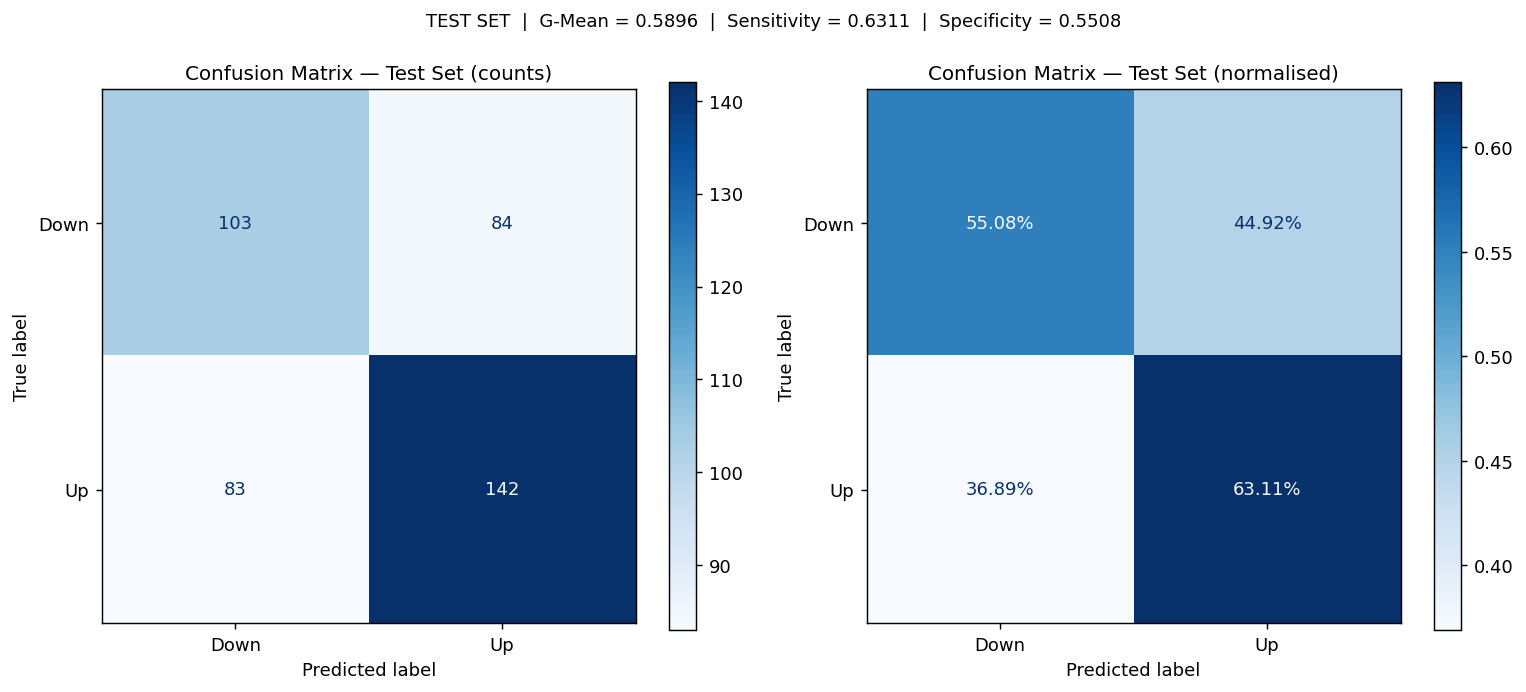

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=['Down', 'Up'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Test Set (counts)', fontsize=11)

# Normalised by true class
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=['Down', 'Up'],
    normalize='true', cmap='Blues', ax=axes[1],
    values_format='.2%'
)
axes[1].set_title('Confusion Matrix — Test Set (normalised)', fontsize=11)

fig.suptitle(
    f'TEST SET  |  G-Mean = {test_gmean:.4f}  |  Sensitivity = {test_sensitivity:.4f}  |  '
    f'Specificity = {test_specificity:.4f}',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  ROC Curve (Test Set + Training CV Folds)

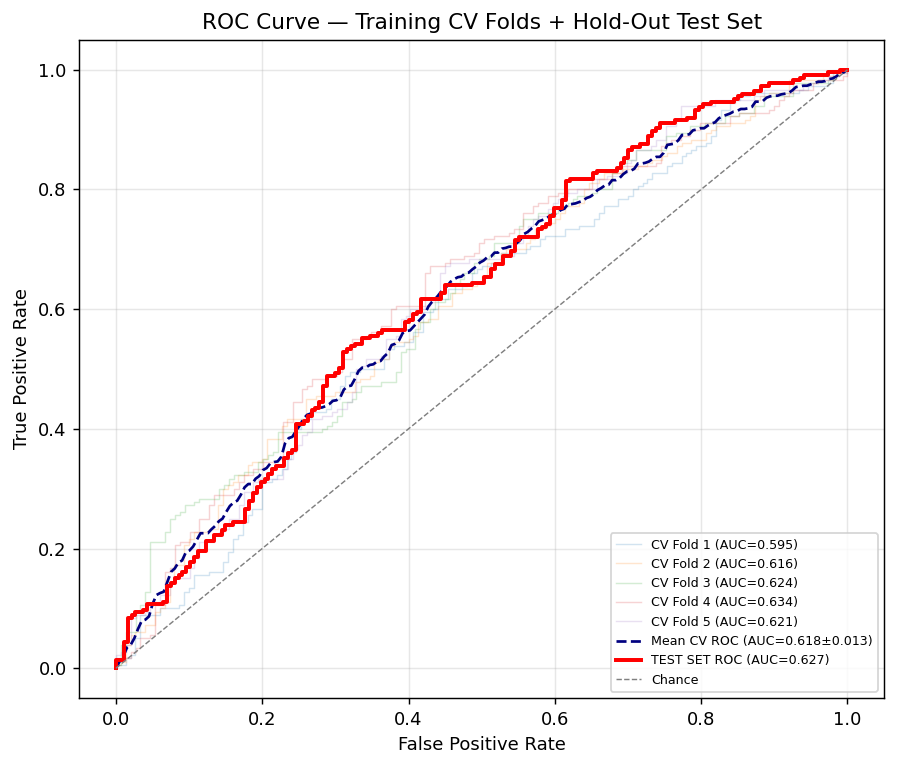

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))

# ── Training CV fold ROCs ─────────────────────────────────────
tprs, aucs_list = [], []
mean_fpr = np.linspace(0, 1, 200)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_tr_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    fold_pipe = clone(best_pipe)
    fold_pipe.fit(X_tr_fold, y_tr_fold)
    y_prob_fold = fold_pipe.predict_proba(X_val_fold)[:, 1]

    fpr, tpr, _ = roc_curve(y_val_fold, y_prob_fold)
    fold_auc = auc(fpr, tpr)
    aucs_list.append(fold_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    ax.plot(fpr, tpr, alpha=0.2, linewidth=0.8,
            label=f'CV Fold {fold_idx+1} (AUC={fold_auc:.3f})')

# Mean CV ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs_list)
std_auc  = np.std(aucs_list)
ax.plot(mean_fpr, mean_tpr, color='navy', linewidth=1.5, linestyle='--',
        label=f'Mean CV ROC (AUC={mean_auc:.3f}±{std_auc:.3f})')

# ── Test set ROC ─────────────────────────────────────────────
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
test_auc = auc(fpr_test, tpr_test)
ax.plot(fpr_test, tpr_test, color='red', linewidth=2.2,
        label=f'TEST SET ROC (AUC={test_auc:.3f})')

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=0.8, label='Chance')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Training CV Folds + Hold-Out Test Set', fontsize=12)
ax.legend(fontsize=7, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Feature Importance: Mean Decrease in Impurity (Gini)

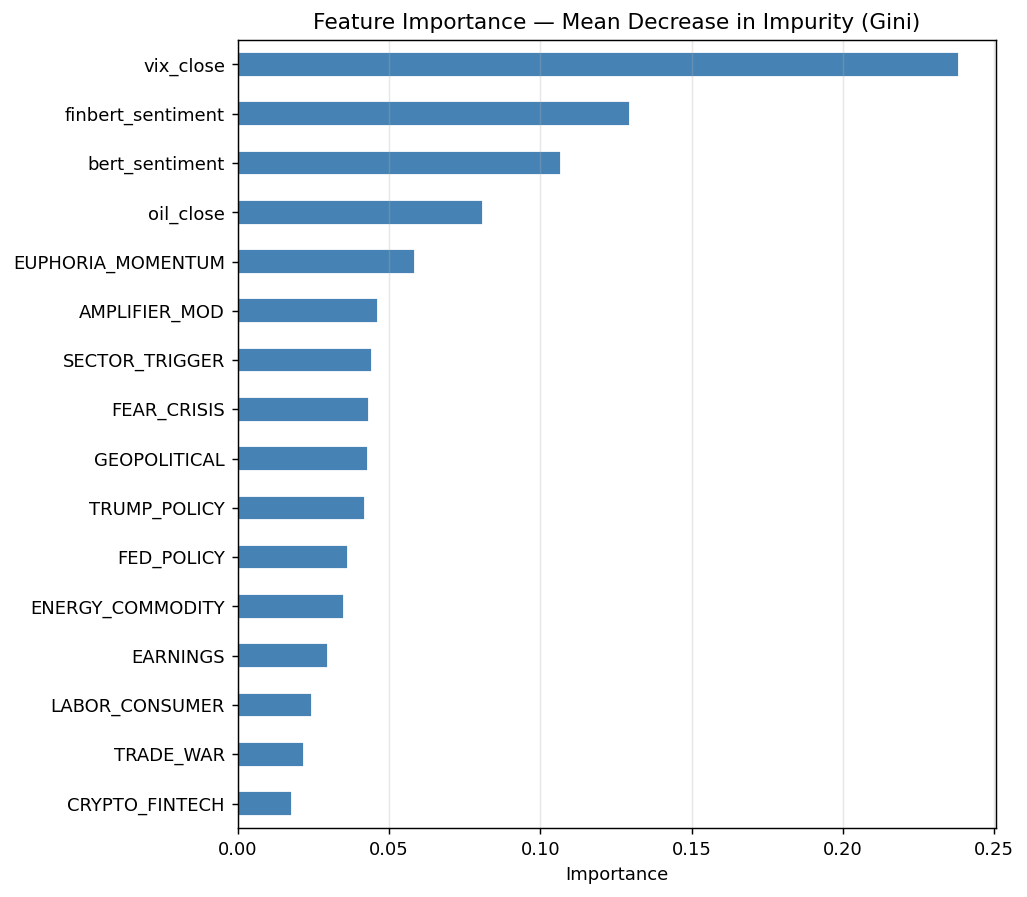

In [14]:
rf_model = best_pipe.named_steps['rf']
mdi = pd.Series(rf_model.feature_importances_, index=feature_cols)
mdi = mdi.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
mdi.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Mean Decrease in Impurity (Gini)', fontsize=12)
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('importance_mdi.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Tabular view of MDI values
mdi.sort_values(ascending=False)

vix_close            0.238554
finbert_sentiment    0.129770
bert_sentiment       0.106717
oil_close            0.080986
EUPHORIA_MOMENTUM    0.058750
AMPLIFIER_MOD        0.046417
SECTOR_TRIGGER       0.044499
FEAR_CRISIS          0.043421
GEOPOLITICAL         0.043006
TRUMP_POLICY         0.041939
FED_POLICY           0.036379
ENERGY_COMMODITY     0.035074
EARNINGS             0.029942
LABOR_CONSUMER       0.024550
TRADE_WAR            0.021994
CRYPTO_FINTECH       0.018002
dtype: float64

---
## Feature Importance: Permutation on Test Set

Computing permutation importance on TEST SET (10 repeats, G-Mean scorer)...


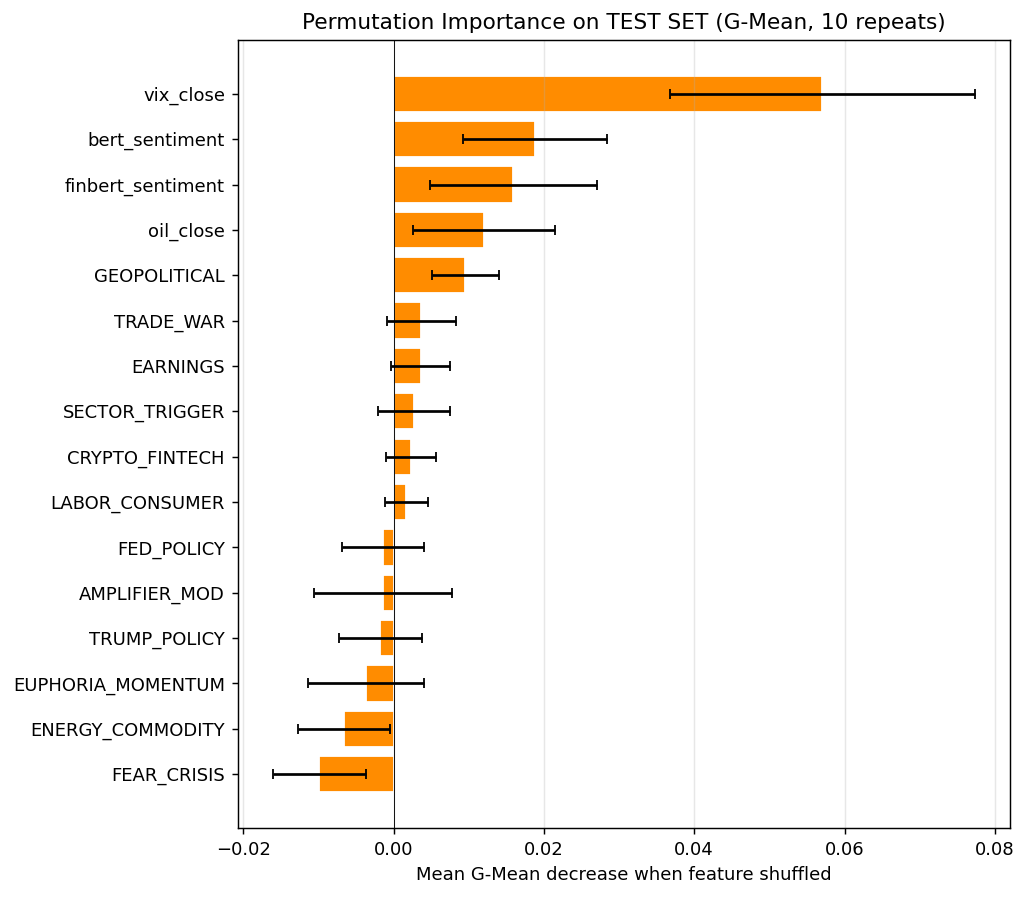

In [ ]:
random.seed(time.time())
print('Computing permutation importance on TEST SET (10 repeats, G-Mean scorer)...')
perm = permutation_importance(
    best_pipe,
    X_test, y_test,           # ← TEST SET, not training set
    scoring=gmean_scorer,
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'mean': perm.importances_mean,
    'std':  perm.importances_std,
}, index=feature_cols).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(perm_df.index, perm_df['mean'], xerr=perm_df['std'],
        color='darkorange', edgecolor='white', capsize=3)
ax.set_title('Permutation Importance on TEST SET (G-Mean, 10 repeats)', fontsize=12)
ax.set_xlabel('Mean G-Mean decrease when feature shuffled')
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('importance_permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Tabular view of permutation importance (test set)
perm_df.sort_values('mean', ascending=False)

,mean,std
vix_close,0.057050,0.020295
bert_sentiment,0.018811,0.009522
finbert_sentiment,0.015939,0.011109
oil_close,0.012067,0.009463
GEOPOLITICAL,0.009508,0.004452
TRADE_WAR,0.003661,0.004599
EARNINGS,0.003580,0.003981
SECTOR_TRIGGER,0.002708,0.004797
CRYPTO_FINTECH,0.002302,0.003371
LABOR_CONSUMER,0.001686,0.002878


---
## Side-by-Side Importance Comparison

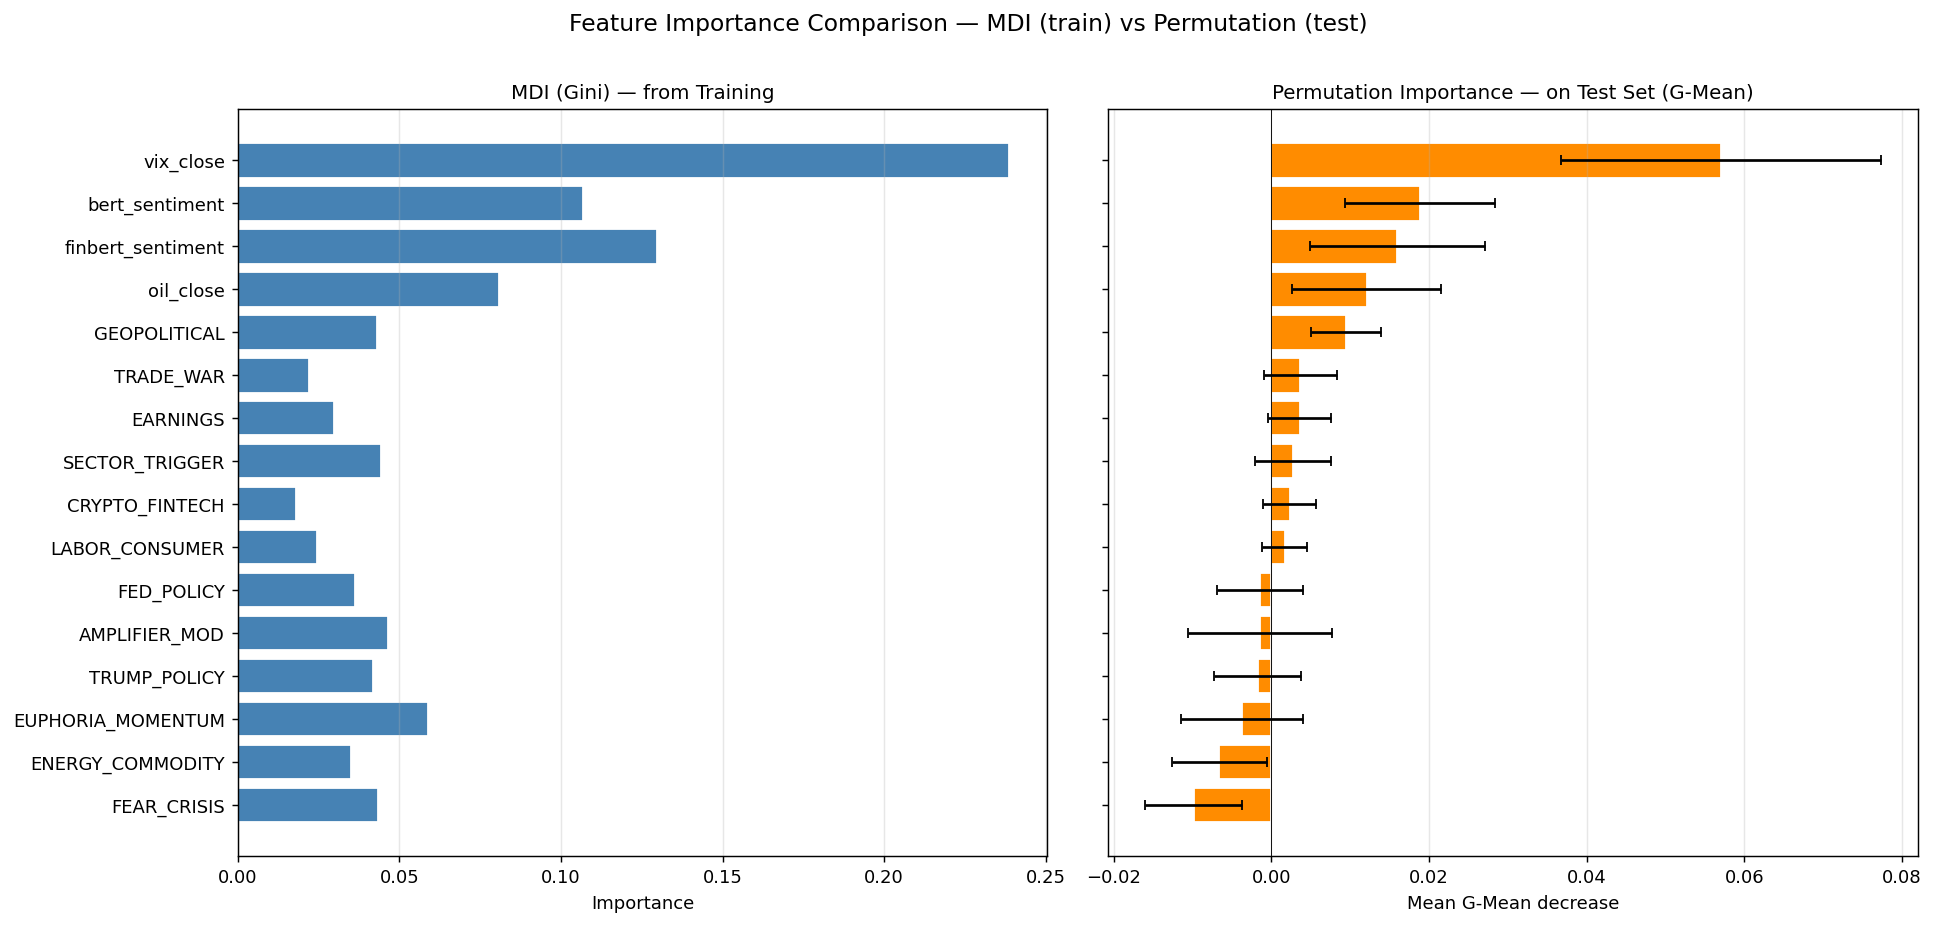

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

order = perm_df.index

axes[0].barh(order, mdi.reindex(order), color='steelblue', edgecolor='white')
axes[0].set_title('MDI (Gini) — from Training', fontsize=11)
axes[0].set_xlabel('Importance')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(order, perm_df.loc[order, 'mean'],
             xerr=perm_df.loc[order, 'std'],
             color='darkorange', edgecolor='white', capsize=3)
axes[1].set_title('Permutation Importance — on Test Set (G-Mean)', fontsize=11)
axes[1].set_xlabel('Mean G-Mean decrease')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('Feature Importance Comparison — MDI (train) vs Permutation (test)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Ranked comparison table
rank_df = pd.DataFrame({
    'MDI': mdi.reindex(feature_cols),
    'Perm_mean': perm_df['mean'].reindex(feature_cols),
    'Perm_std':  perm_df['std'].reindex(feature_cols),
})
rank_df['MDI_rank']  = rank_df['MDI'].rank(ascending=False).astype(int)
rank_df['Perm_rank'] = rank_df['Perm_mean'].rank(ascending=False).astype(int)
print(rank_df.sort_values('Perm_rank').to_string())

                        MDI  Perm_mean  Perm_std  MDI_rank  Perm_rank
vix_close          0.238554   0.057050  0.020295         1          1
bert_sentiment     0.106717   0.018811  0.009522         3          2
finbert_sentiment  0.129770   0.015939  0.011109         2          3
oil_close          0.080986   0.012067  0.009463         4          4
GEOPOLITICAL       0.043006   0.009508  0.004452         9          5
TRADE_WAR          0.021994   0.003661  0.004599        15          6
EARNINGS           0.029942   0.003580  0.003981        13          7
SECTOR_TRIGGER     0.044499   0.002708  0.004797         7          8
CRYPTO_FINTECH     0.018002   0.002302  0.003371        16          9
LABOR_CONSUMER     0.024550   0.001686  0.002878        14         10
FED_POLICY         0.036379  -0.001410  0.005466        11         11
AMPLIFIER_MOD      0.046417  -0.001411  0.009130         6         12
TRUMP_POLICY       0.041939  -0.001756  0.005480        10         13
EUPHORIA_MOMENTUM  0

---
## SHAP Analysis (Shapley Additive Explanations)

### Transform Test Features & Compute SHAP Values

In [20]:
# Transform TEST set through the fitted imputer + scaler (no re-fitting!)
X_test_transformed = best_pipe.named_steps['imputer'].transform(X_test)
X_test_transformed = best_pipe.named_steps['scaler'].transform(X_test_transformed)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_cols, index=X_test.index)

print(f'Transformed test set shape: {X_test_transformed.shape}')

Transformed test set shape: (412, 16)


In [21]:
print('Computing SHAP values on TEST SET (TreeExplainer)...')
explainer = shap.TreeExplainer(rf_model)

shap_explanation = explainer(X_test_transformed)

raw_vals = shap_explanation.values

if raw_vals.ndim == 3:
    shap_up = raw_vals[:, :, 1]
    base_value_up = shap_explanation.base_values[:, 1][0]
elif raw_vals.ndim == 2:
    shap_up = raw_vals
    bv = shap_explanation.base_values
    base_value_up = bv[0] if hasattr(bv, '__len__') else bv
else:
    raise ValueError(f'Unexpected SHAP values shape: {raw_vals.shape}')

print(f'SHAP values shape : {shap_up.shape}')
print(f'Base value (Up)   : {base_value_up:.4f}')
assert shap_up.shape == X_test_transformed.shape
print('Done.')

Computing SHAP values on TEST SET (TreeExplainer)...
SHAP values shape : (412, 16)
Base value (Up)   : 0.5002
Done.


### Global: Mean Absolute SHAP Bar Plot

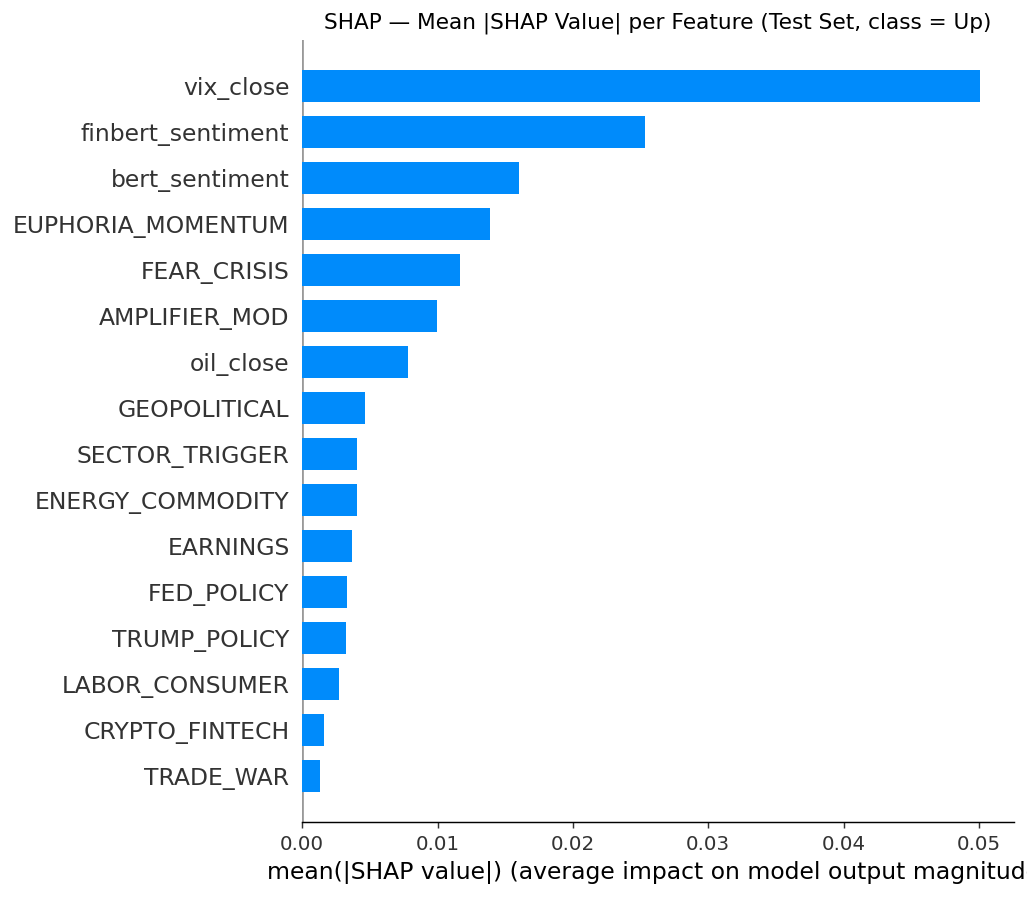

In [22]:
fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(
    shap_up, X_test_transformed,
    plot_type='bar', show=False, plot_size=None,
)
plt.title('SHAP — Mean |SHAP Value| per Feature (Test Set, class = Up)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar_test.png', dpi=150, bbox_inches='tight')
plt.show()

### Global: Beeswarm Plot

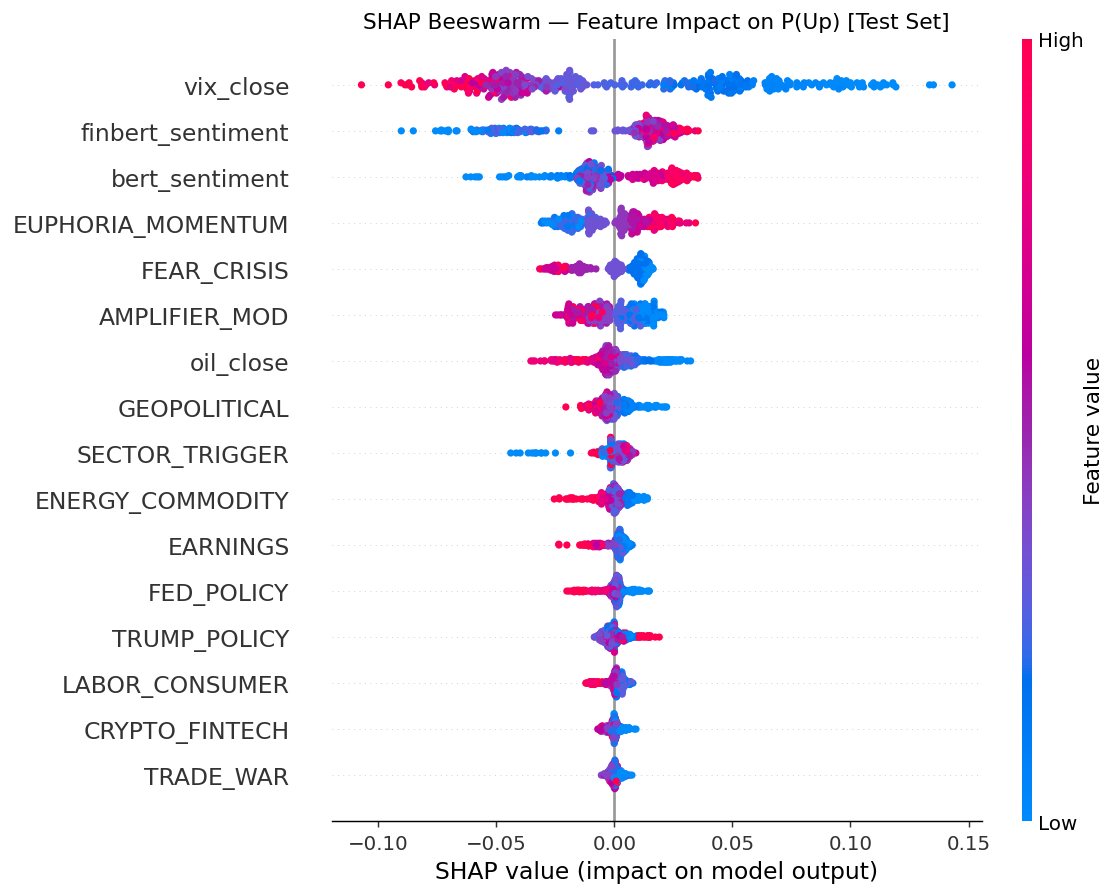

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_up, X_test_transformed,
    show=False, plot_size=None,
)
plt.title('SHAP Beeswarm — Feature Impact on P(Up) [Test Set]', fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm_test.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP vs. MDI Comparison Table

In [24]:
mean_abs_shap = pd.Series(np.abs(shap_up).mean(axis=0), index=feature_cols)

comparison = pd.DataFrame({
    'SHAP_mean_abs': mean_abs_shap,
    'MDI_gini':      pd.Series(rf_model.feature_importances_, index=feature_cols),
})
comparison['SHAP_rank'] = comparison['SHAP_mean_abs'].rank(ascending=False).astype(int)
comparison['MDI_rank']  = comparison['MDI_gini'].rank(ascending=False).astype(int)
comparison = comparison.sort_values('SHAP_rank')

print('FEATURE IMPORTANCE COMPARISON — SHAP (test set) vs MDI (training):')
print(comparison.to_string())

FEATURE IMPORTANCE COMPARISON — SHAP (test set) vs MDI (training):
                   SHAP_mean_abs  MDI_gini  SHAP_rank  MDI_rank
vix_close               0.050085  0.238554          1         1
finbert_sentiment       0.025296  0.129770          2         2
bert_sentiment          0.016037  0.106717          3         3
EUPHORIA_MOMENTUM       0.013881  0.058750          4         5
FEAR_CRISIS             0.011659  0.043421          5         8
AMPLIFIER_MOD           0.009944  0.046417          6         6
oil_close               0.007852  0.080986          7         4
GEOPOLITICAL            0.004652  0.043006          8         9
SECTOR_TRIGGER          0.004065  0.044499          9         7
ENERGY_COMMODITY        0.004024  0.035074         10        12
EARNINGS                0.003711  0.029942         11        13
FED_POLICY              0.003322  0.036379         12        11
TRUMP_POLICY            0.003268  0.041939         13        10
LABOR_CONSUMER          0.002733  0.0

### Dependence Plots (Top 4 Features by SHAP on Test Set)

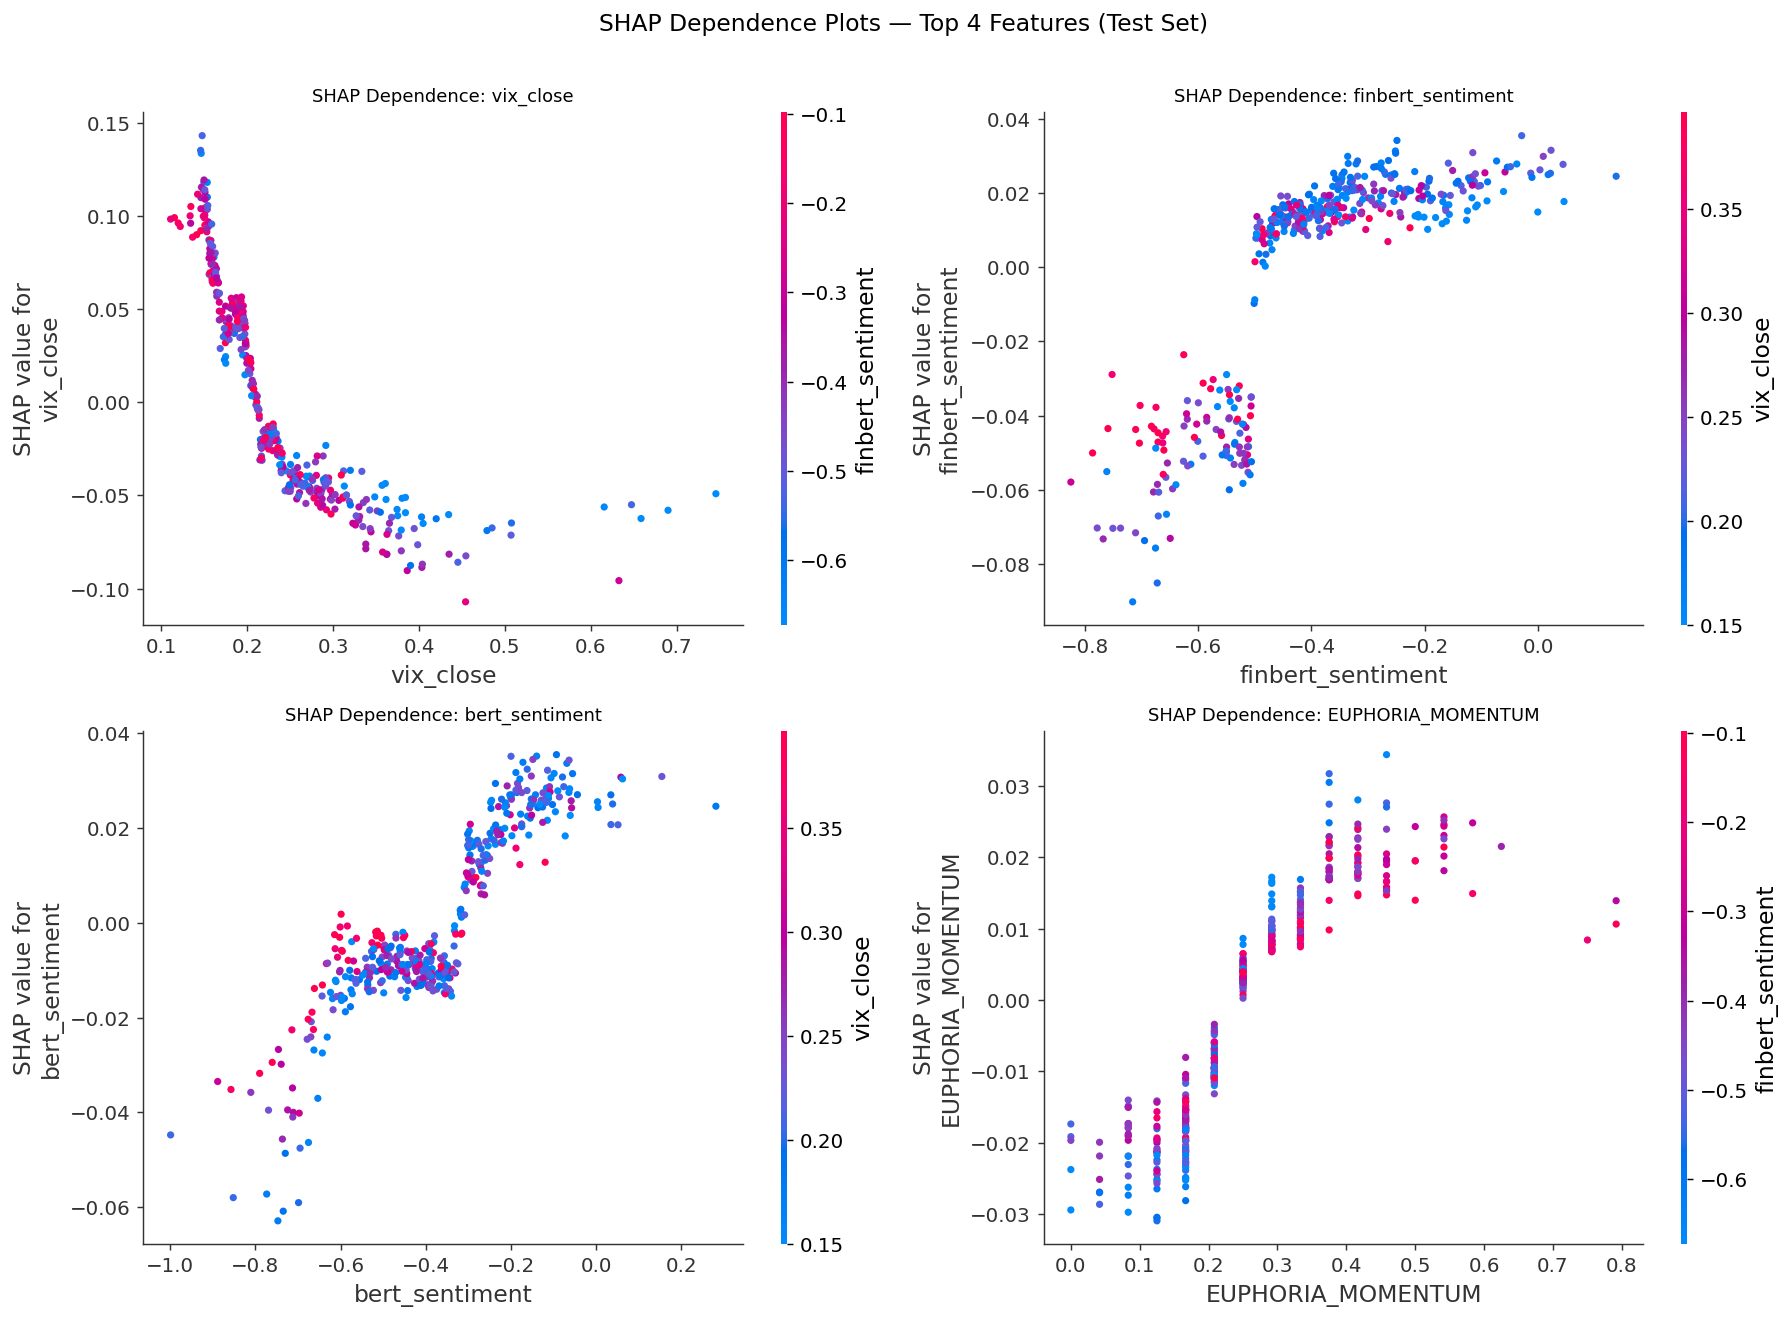

In [25]:
top4 = mean_abs_shap.nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top4):
    shap.dependence_plot(
        feat, shap_up, X_test_transformed,
        interaction_index='auto',
        ax=ax, show=False,
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=10)

fig.suptitle('SHAP Dependence Plots — Top 4 Features (Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('shap_dependence_top4_test.png', dpi=150, bbox_inches='tight')
plt.show()

### Local Explanations: Waterfall Plots

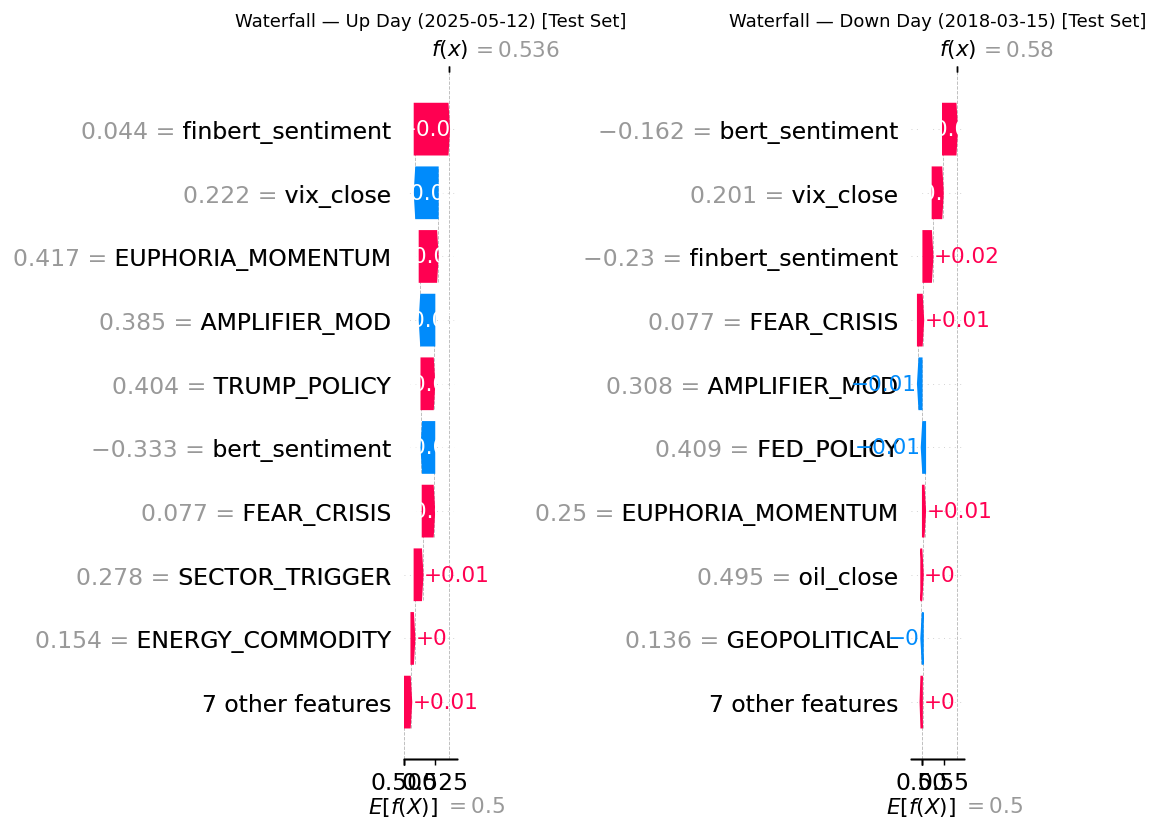

In [26]:
# Select one Up and one Down observation from the TEST set
up_mask = y_test == 1
down_mask = y_test == 0

up_idx   = y_test[up_mask].index[0]
down_idx = y_test[down_mask].index[0]

up_pos   = X_test_transformed.index.get_loc(up_idx)
down_pos = X_test_transformed.index.get_loc(down_idx)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_up[up_pos],
        base_values=base_value_up,
        data=X_test_transformed.iloc[up_pos].values,
        feature_names=feature_cols,
    ),
    show=False,
)
axes[0].set_title(f'Waterfall — Up Day ({up_idx.date()}) [Test Set]', fontsize=10)

plt.sca(axes[1])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_up[down_pos],
        base_values=base_value_up,
        data=X_test_transformed.iloc[down_pos].values,
        feature_names=feature_cols,
    ),
    show=False,
)
axes[1].set_title(f'Waterfall — Down Day ({down_idx.date()}) [Test Set]', fontsize=10)

plt.tight_layout()
plt.savefig('shap_waterfall_test.png', dpi=150, bbox_inches='tight')
plt.show()

### Interactive Force Plot (HTML)

In [27]:
shap.initjs()

force = shap.force_plot(
    base_value_up,
    shap_up,
    X_test_transformed,
    feature_names=feature_cols,
)
shap.save_html('shap_force_plot_test.html', force)
print('Saved: shap_force_plot_test.html  (open in browser for interactive view)')

Saved: shap_force_plot_test.html  (open in browser for interactive view)
